# 线性回归完整实现

流程：
- 生成一份可控的线性数据集
- 从零实现模型、损失函数、优化算法
- 训练并观察损失下降

In [1]:
import random
import torch
from torch import Tensor
import matplotlib.pyplot as plt

## 1. 生成数据

设定参数 w 和 b，然后构造输入 X，再加上噪声得到标签 y。

- torch.normal(mean, std, size) 生成正态分布数据
- matmul为矩阵乘法matrix multiply
- 加入噪声让数据更贴近真实场景

In [2]:
def synthetic_data(w, b, num_examples):  #@save
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape) # 添加噪声
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([-1.9036, -1.4909]) 
label: tensor([5.4580])


可视化其中一个特征与标签的关系，应该接近一条直线。
- features[:, 1]：选择 features 的第1列（所有样本的第二个特征）
- .detach()：从计算图中分离张量，不再跟踪梯度，用于从训练中取出数值而不影响梯度计算。
- .numpy()：将 PyTorch 张量转换为 NumPy 数组，Matplotlib 需要 NumPy 数组作为输入。
- .cpu():将张量移动到 CPU 上，确保在使用 Matplotlib 进行可视化时数据在 CPU 上。
- .ravel()：将多维数组展平为一维数组，适用于散点图的 x 和 y 数据。

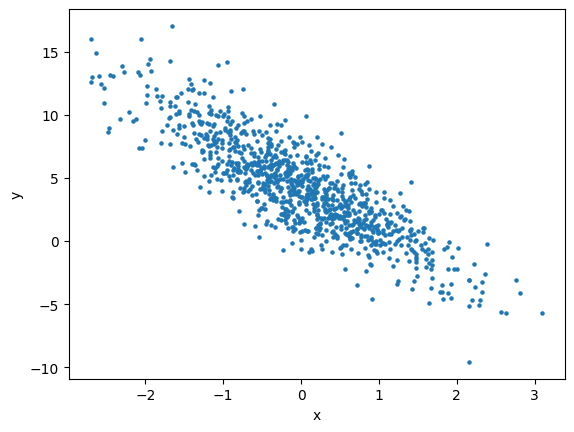

In [3]:
x = features[:, 1].detach().cpu().numpy().ravel()
y = labels.detach().cpu().numpy().ravel()
plt.scatter(x, y, s=5)
plt.xlabel('x'); plt.ylabel('y'); plt.show()

## 2. 小批量数据迭代器

训练时一般使用小批量随机梯度下降（SGD）。
- 先打乱索引
- 再切分成批量大小 batch_size
- 每次 yield 一小批数据

In [4]:
def data_iter(batch_size: int, features: Tensor, labels: Tensor):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:i + batch_size])
        yield features[batch_indices], labels[batch_indices]

## 3. 初始化模型参数

我们要学习的是参数 w 和 b。
- $requires_{grad}=True $让 PyTorch 记录梯度
- torch.zeros(1) 初始化

In [5]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

## 4. 定义模型、损失和优化

线性回归模型：$ y_{hat} = X w + b $  
平方损失：$ loss = \frac{1}{2} (y_{hat} - y)^2 $

sgd 的核心是用梯度更新参数,公式为：$ \theta = \theta - \eta \nabla_{\theta} loss $
- $\theta$：参数（w 或 b）
- $\nabla_{\theta} loss$：损失函数关于参数的梯度
eta:学习率，控制更新步伐的大小

In [6]:
def linreg(X: Tensor, w: Tensor, b: Tensor):
    return X @ w + b

def squared_loss(y_hat: Tensor, y: Tensor):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

def sgd(params, lr: float, batch_size: int):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

## 5. 训练循环

- 正向计算得到预测值
- 计算损失并反向传播
- 用 sgd 更新参数
- 记录每个 epoch（完整遍历一次训练数据集的过程）的平均损失
- with torch.no_grad():在with语句块中，所有计算都不会被自动求导记录，因此不会占用额外的内存，也不会进行梯度计算。

- batch_size:每次更新使用的样本数量，较小的 batch_size 会使训练更稳定，但可能需要更多的迭代次数。
- lr:学习率，控制更新步伐的大小

In [7]:
lr = 0.03
num_epochs = 5
batch_size = 10
losses = []

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        y_hat = linreg(X, w, b)
        l = squared_loss(y_hat, y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = squared_loss(linreg(features, w, b), labels)
        mean_l = float(train_l.mean())
        losses.append(mean_l)
    print(f'epoch {epoch + 1}, loss {mean_l:.6f}')

epoch 1, loss 0.044913
epoch 2, loss 0.000187
epoch 3, loss 0.000046
epoch 4, loss 0.000045
epoch 5, loss 0.000045


绘制损失曲线，模型确实在收敛。

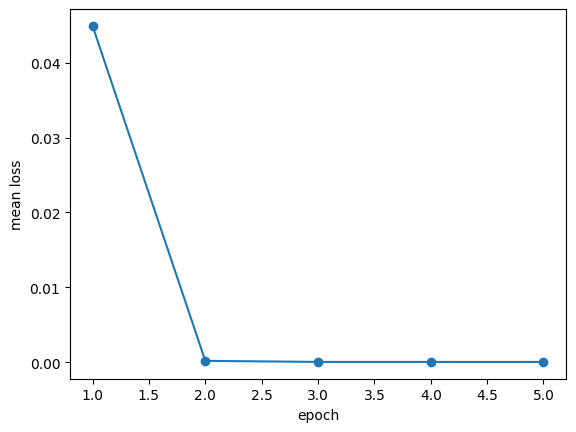

In [8]:
plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.xlabel('epoch')
plt.ylabel('mean loss')
plt.show()

## 6. 对比学到的参数

如果训练正常，学到的 w 和 b 应接近真实值。

In [9]:
print('estimated w:', w.reshape(-1).tolist())
print('estimated b:', float(b))
print('true w:', true_w.tolist())
print('true b:', true_b)

estimated w: [1.999616265296936, -3.400346040725708]
estimated b: 4.19984245300293
true w: [2.0, -3.4000000953674316]
true b: 4.2


## 改变超参数，观察对训练的影响。
- 增大学习率可能导致训练不稳定，损失震荡甚至发散
- 减小学习率可能导致训练过慢，损失下降缓慢

epoch 1, loss 0.000068


epoch 2, loss 0.000066
epoch 3, loss 0.000046
epoch 4, loss 0.000045
epoch 5, loss 0.000060
epoch 6, loss 0.000088
epoch 7, loss 0.000058
epoch 8, loss 0.000055
epoch 9, loss 0.000056
epoch 10, loss 0.000092


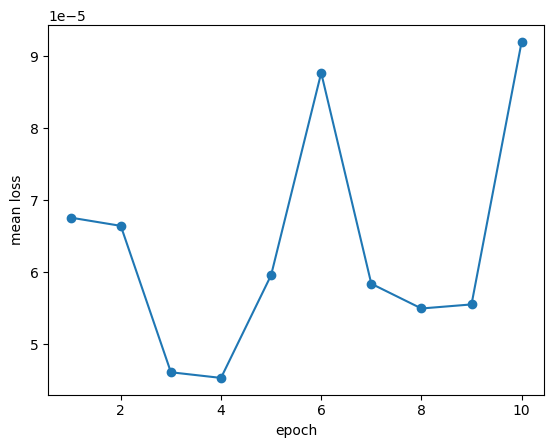

In [10]:
lr = 1
num_epochs = 10
batch_size = 10
losses = []

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        y_hat = linreg(X, w, b)
        l = squared_loss(y_hat, y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = squared_loss(linreg(features, w, b), labels)
        mean_l = float(train_l.mean())
        losses.append(mean_l)
    print(f'epoch {epoch + 1}, loss {mean_l:.6f}')
plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.xlabel('epoch')
plt.ylabel('mean loss')
plt.show()

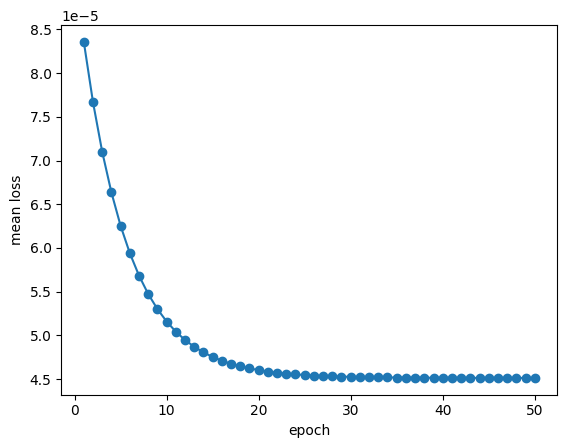

In [11]:
lr = 0.001
num_epochs = 50
batch_size = 10
losses = []

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        y_hat = linreg(X, w, b)
        l = squared_loss(y_hat, y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad(): 
        train_l = squared_loss(linreg(features, w, b), labels)
        mean_l = float(train_l.mean())
        losses.append(mean_l)
    #print(f'epoch {epoch + 1}, loss {mean_l:.6f}')

plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.xlabel('epoch')
plt.ylabel('mean loss')
plt.show()